In [3]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.0/461.0 kB 13.0 MB/s eta 0:00:00


# imports & data loading

In [7]:
!pip install xgboost==2.1.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 20.1 MB/s eta 0:00:00a 0:00:01


In [1]:
print("..")

..


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import lightgbm as lgb
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print(xgb.__version__)

2.1.4


In [7]:
train_tr = pd.read_csv('INFO442Data/train_transaction.csv')
id_tr = pd.read_csv('INFO442Data/train_identity.csv')

X = train_tr.merge(id_tr, on='TransactionID', how='left')
y = X['isFraud']

X.drop(['isFraud'], axis=1, inplace=True)

# Drop low info columns

In [9]:
# Columns with >90% missing values
many_null_cols = [
    col for col in X.columns
    if X[col].isnull().mean() > 0.90
]

# Columns where one value accounts for >90% of entries
big_top_value_cols = [
    col for col in X.columns
    if X[col].value_counts(dropna=False, normalize=True).iloc[0] > 0.90
]

# Columns with only one unique value
one_value_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

cols_to_drop = list(set(
    many_null_cols +
    big_top_value_cols +
    one_value_cols
))

X.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns")

Dropped 66 columns


# Feature Engineering

In [11]:
# TransactionAmt features
X['TransactionAmt_to_mean_card1'] = X['TransactionAmt'] / X.groupby('card1')['TransactionAmt'].transform('mean')
X['TransactionAmt_to_mean_card4'] = X['TransactionAmt'] / X.groupby('card4')['TransactionAmt'].transform('mean')
X['TransactionAmt_to_std_card1'] = X['TransactionAmt'] / X.groupby('card1')['TransactionAmt'].transform('std')
X['TransactionAmt_to_std_card4'] = X['TransactionAmt'] / X.groupby('card4')['TransactionAmt'].transform('std')

# id_02 features (if available)
if 'id_02' in X.columns:
    X['id_02_to_mean_card1'] = X['id_02'] / X.groupby('card1')['id_02'].transform('mean')
    X['id_02_to_mean_card4'] = X['id_02'] / X.groupby('card4')['id_02'].transform('mean')
    X['id_02_to_std_card1'] = X['id_02'] / X.groupby('card1')['id_02'].transform('std')
    X['id_02_to_std_card4'] = X['id_02'] / X.groupby('card4')['id_02'].transform('std')

# D15 features (if available)
if 'D15' in X.columns:
    X['D15_to_mean_card1'] = X['D15'] / X.groupby('card1')['D15'].transform('mean')
    X['D15_to_mean_card4'] = X['D15'] / X.groupby('card4')['D15'].transform('mean')
    X['D15_to_std_card1'] = X['D15'] / X.groupby('card1')['D15'].transform('std')
    X['D15_to_std_card4'] = X['D15'] / X.groupby('card4')['D15'].transform('std')

    X['D15_to_mean_addr1'] = X['D15'] / X.groupby('addr1')['D15'].transform('mean')
    X['D15_to_mean_addr2'] = X['D15'] / X.groupby('addr2')['D15'].transform('mean')
    X['D15_to_std_addr1'] = X['D15'] / X.groupby('addr1')['D15'].transform('std')
    X['D15_to_std_addr2'] = X['D15'] / X.groupby('addr2')['D15'].transform('std')

# Email domain decomposition
if 'P_emaildomain' in X.columns:
    X[['P_emaildomain_1', 'P_emaildomain_2', 'P_emaildomain_3']] = (
        X['P_emaildomain'].str.split('.', expand=True)
    )

if 'R_emaildomain' in X.columns:
    X[['R_emaildomain_1', 'R_emaildomain_2', 'R_emaildomain_3']] = (
        X['R_emaildomain'].str.split('.', expand=True)
    )

# Frequency Encoding

In [13]:
X['null_count'] = X.isnull().sum(axis=1)

freq_cols = [
    'ProductCD',
    'card1','card2','card3','card4','card5','card6',
    'addr1','addr2',
    'P_emaildomain','R_emaildomain',
    'DeviceType','DeviceInfo'
]

for col in freq_cols:
    if col in X.columns:
        freq = X[col].value_counts(dropna=False)
        X[col + '_FE'] = X[col].map(freq)

# Replace infinite vals with NaN

In [15]:
def clean_inf_nan(df):
    return df.replace([np.inf, -np.inf], np.nan)

X = clean_inf_nan(X)

# Drop identifiers

In [17]:
X.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)

# Convert Categorical Columns

In [19]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype('category')

# Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create + train lgbm model

In [23]:
train_data = lgb.Dataset(X_train, label=y_train)

In [25]:
lgb_params = {'num_leaves': 256,
          'min_child_samples': 79,
          'objective': 'binary',
          'max_depth': 13,
          'learning_rate': 0.03,
          'boosting_type': 'gbdt',
          'subsample_freq': 3,
          'subsample': 0.9,
          'bagging_seed': 11,
          'metric': 'auc',
          "verbosity": -1,
          'reg_alpha': 0.3,
          'reg_lambda': 0.3,
          'colsample_bytree': 0.9
         }

result_lgb = lgb.train(lgb_params, train_data, num_boost_round=100)

In [27]:
y_pred_lgb = result_lgb.predict(X_test)

In [29]:
accuracy_lgb = accuracy_score(y_test, (y_pred_lgb > 0.5).astype(int))
roc_auc_lgb = roc_auc_score(y_test, y_pred_lgb)

print(f'Accuracy: {accuracy_lgb}')
print(f'ROC AUC: {roc_auc_lgb}')

Accuracy: 0.9794764114200563
ROC AUC: 0.9454171351880541


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

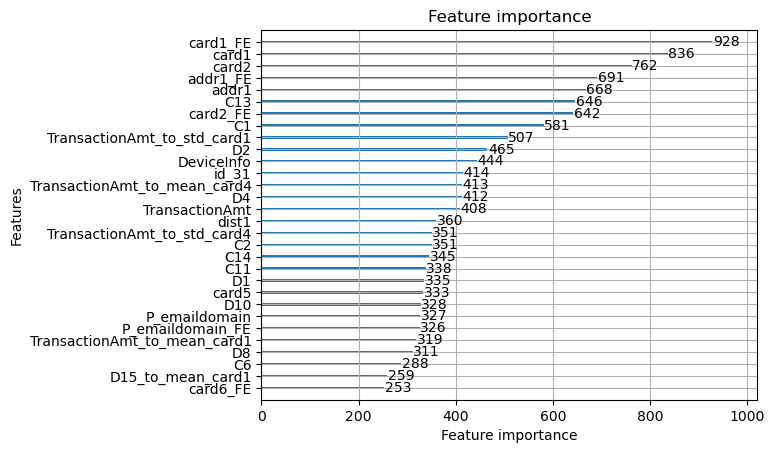

In [31]:
lgb.plot_importance(result_lgb, height=0.2, title='Feature importance', xlabel='Feature importance', ylabel='Features', importance_type='auto', grid=True, max_num_features=30, precision=3)
     

# XGB

In [33]:
train_data = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
test_data = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [35]:
xgb_params = {
    'max_leaves': 256,
    'min_child_weight': 79,
    'objective': 'binary:logistic',
    'max_depth': 13,
    'eta': 0.03,
    'tree_method': 'hist',
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'seed': 11,
    'eval_metric': 'auc',
    'verbosity': 0,
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'grow_policy': 'lossguide'  # needed so max_leaves is actually respected
}

result_xgb = xgb.train(
    xgb_params,
    train_data,
    num_boost_round=100,
    evals=[(train_data, 'train'), (test_data, 'valid')],
    verbose_eval=10
)
     

[0]	train-auc:0.86976	valid-auc:0.86598
[10]	train-auc:0.88972	valid-auc:0.88748
[20]	train-auc:0.89474	valid-auc:0.89149
[30]	train-auc:0.89875	valid-auc:0.89448
[40]	train-auc:0.90156	valid-auc:0.89696
[50]	train-auc:0.90439	valid-auc:0.89937
[60]	train-auc:0.90759	valid-auc:0.90208
[70]	train-auc:0.91133	valid-auc:0.90547
[80]	train-auc:0.91434	valid-auc:0.90812
[90]	train-auc:0.91672	valid-auc:0.91022
[99]	train-auc:0.91884	valid-auc:0.91223


In [37]:
y_pred_xgb = result_xgb.predict(test_data)

In [39]:
accuracy_xgb = accuracy_score(y_test, (y_pred_xgb > 0.5).astype(int))
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print(f'Accuracy: {accuracy_xgb}')
print(f'ROC AUC: {roc_auc_xgb}')

Accuracy: 0.9743031801402107
ROC AUC: 0.9122324353763454


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

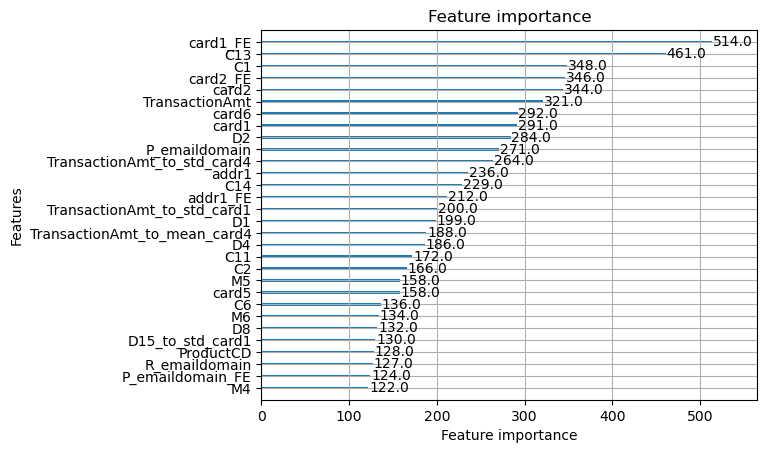

In [41]:
xgb.plot_importance(result_xgb, height=0.2, title='Feature importance', xlabel='Feature importance', ylabel='Features', max_num_features=30, grid=True)


# Compare Feature Importance

In [43]:
lgb_imp = pd.DataFrame({
    'feature': result_lgb.feature_name(),
    'lgb_gain': result_lgb.feature_importance(importance_type='gain'),
    'lgb_split': result_lgb.feature_importance(importance_type='split')
})

xgb_gain_dict = result_xgb.get_score(importance_type='gain')
xgb_weight_dict = result_xgb.get_score(importance_type='weight')  # weight ~= split count

all_features = X_train.columns.tolist()
xgb_imp = pd.DataFrame({
    'feature': all_features,
    'xgb_gain': [xgb_gain_dict.get(f, 0.0) for f in all_features],
    'xgb_split': [xgb_weight_dict.get(f, 0.0) for f in all_features]
})

In [45]:
imp = lgb_imp.merge(xgb_imp, on='feature', how='outer').fillna(0)

# Normalize gain within each model so they're on a comparable 0-1 scale
imp['lgb_gain_norm'] = imp['lgb_gain'] / imp['lgb_gain'].sum()
imp['xgb_gain_norm'] = imp['xgb_gain'] / imp['xgb_gain'].sum()

# Rank each model's features
imp['lgb_rank'] = imp['lgb_gain_norm'].rank(ascending=False, method='min')
imp['xgb_rank'] = imp['xgb_gain_norm'].rank(ascending=False, method='min')
imp['rank_diff'] = (imp['lgb_rank'] - imp['xgb_rank']).abs()

imp_sorted = imp.sort_values('lgb_gain_norm', ascending=False)
imp_sorted.head(30)

,feature,lgb_gain,lgb_split,xgb_gain,xgb_split,lgb_gain_norm,xgb_gain_norm,lgb_rank,xgb_rank,rank_diff
209,V258,234719.953799,47,2699.495850,63.0,0.178286,0.119568,1.0,1.0,0.0
0,C1,75924.468901,581,180.393677,348.0,0.057670,0.007990,2.0,22.0,20.0
5,C14,67258.218163,345,256.516968,229.0,0.051087,0.011362,3.0,16.0,13.0
244,V294,51574.280845,82,598.526489,71.0,0.039174,0.026510,4.0,6.0,2.0
4,C13,38376.513081,646,79.361397,461.0,0.029150,0.003515,5.0,50.0,45.0
35,DeviceInfo,35176.925125,444,33.625401,22.0,0.026719,0.001489,6.0,124.0,118.0
28,D2,32778.613052,465,76.889771,284.0,0.024898,0.003406,7.0,52.0,45.0
55,R_emaildomain,31314.827461,102,44.159576,127.0,0.023786,0.001956,8.0,95.0,87.0
357,card2,22664.391896,762,22.499939,344.0,0.017215,0.000997,9.0,179.0,170.0
356,card1_FE,21168.147600,928,12.442731,514.0,0.016079,0.000551,10.0,259.0,249.0


In [47]:
corr, pval = spearmanr(imp['lgb_gain_norm'], imp['xgb_gain_norm'])
print(f'Spearman rank correlation between LGBM and XGBoost importances: {corr:.3f} (p={pval:.3g})')

# Features that swing the most between the two models' opinions of them
print("\nFeatures both models rank in their combined top 20 but disagree on:")
top_by_either = imp[(imp['lgb_rank'] <= 20) | (imp['xgb_rank'] <= 20)]
print(top_by_either.sort_values('rank_diff', ascending=False)[
    ['feature', 'lgb_rank', 'xgb_rank', 'rank_diff']
].head(15))
     


Spearman rank correlation between LGBM and XGBoost importances: 0.575 (p=1.28e-36)

Features both models rank in their combined top 20 but disagree on:
            feature  lgb_rank  xgb_rank  rank_diff
356        card1_FE      10.0     259.0      249.0
355           card1      11.0     221.0      210.0
208            V257     198.0       4.0      194.0
342             V90     200.0      11.0      189.0
196            V246     185.0       2.0      183.0
351           addr1      15.0     185.0      170.0
357           card2       9.0     179.0      170.0
173            V225     172.0       5.0      167.0
358        card2_FE      14.0     165.0      151.0
272            V332     170.0      19.0      151.0
352        addr1_FE      13.0     163.0      150.0
60   TransactionAmt      17.0     147.0      130.0
218            V266     139.0      14.0      125.0
35       DeviceInfo       6.0     124.0      118.0
147            V201     101.0       3.0       98.0


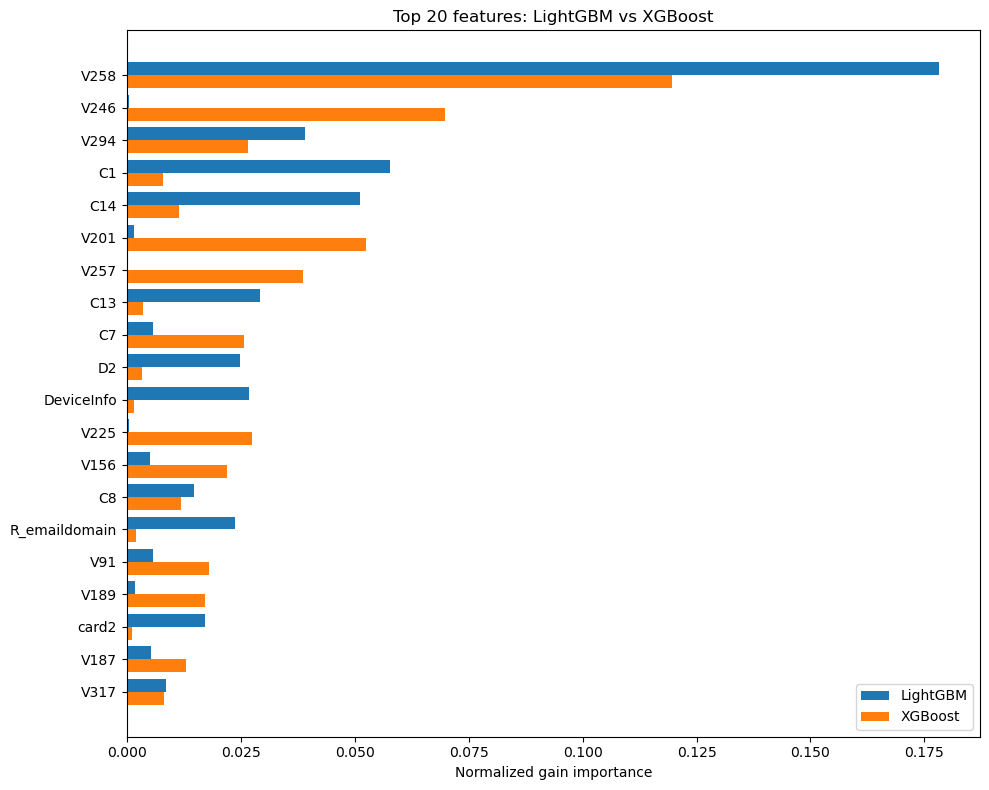

In [49]:
top_n = 20
imp['combined_score'] = imp['lgb_gain_norm'] + imp['xgb_gain_norm']
top_features = imp.sort_values('combined_score', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_features))
width = 0.4

ax.barh(y_pos - width/2, top_features['lgb_gain_norm'], height=width, label='LightGBM')
ax.barh(y_pos + width/2, top_features['xgb_gain_norm'], height=width, label='XGBoost')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Normalized gain importance')
ax.set_title(f'Top {top_n} features: LightGBM vs XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

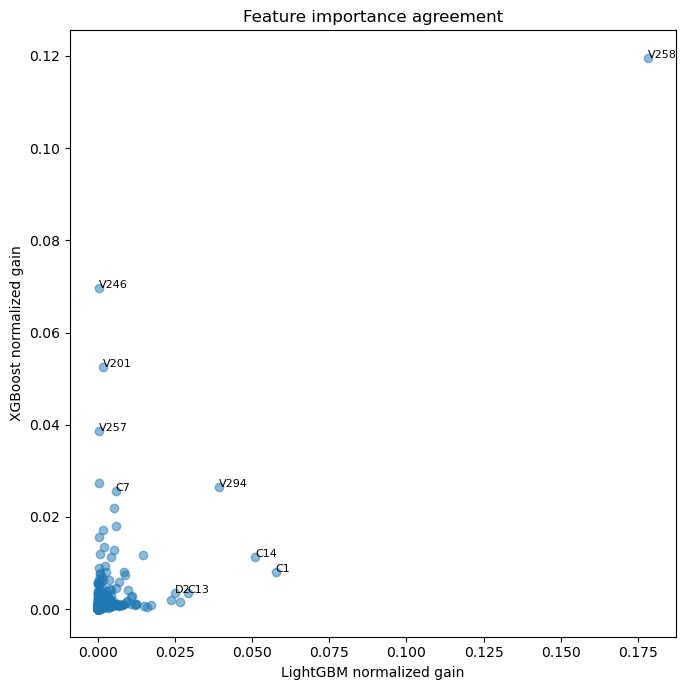

In [51]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(imp['lgb_gain_norm'], imp['xgb_gain_norm'], alpha=0.5)

# label the biggest outliers / most important points
for _, row in top_features.head(10).iterrows():
    ax.annotate(row['feature'], (row['lgb_gain_norm'], row['xgb_gain_norm']), fontsize=8)

ax.set_xlabel('LightGBM normalized gain')
ax.set_ylabel('XGBoost normalized gain')
ax.set_title('Feature importance agreement')
plt.tight_layout()
plt.show()

# Summary

## LGBM:
- top features (engineered): transaction amount to mean/std deviation for cards 1 & 4, card1_FE, various email_FE, card2_FE, card5_FE,card6_FE, D15_to_card1_FE
- other top features: cards 1/2/5, various C & D columns, id_31, deviceinfo, transaction amount

## XGB (only pointing out differences):
- top features (engineered): no differences except in order (insignificant differences overall by my judgment)
- other top features: various M cols, more cards (different ranking as well), C & D columns much more important 

## Comparison Summary

- performance essentially exactly the same overall (accuracy, ROC, importance agreement plot similar as well)
- only different top features
- engineered card features seem most consistently important as well as email and address
- V columns not most important to each (none in top 30) but show up in comparison plot
- comparison plot mostly C, D, and V's
- no engineered features in comparison plot (interesting considering cards 1 & 4 seemed to be in both)
- patterns in engineered vs. not engineered plots very similar (when simply observing visually)
- spearman rank table significantly different